# Cats vs Dogs Classification with PyTorch (Windows + GPU Friendly)

This notebook does 4 things:
1. Prepare the dataset from archive/PetImages or archieve/PetImages
2. Train a CNN using PyTorch
3. Plot training performance
4. Predict a new image from URL or local Windows path

For RTX 4060, PyTorch will use CUDA automatically if installed with CUDA support.

## 0) One-Time Install for PyTorch GPU

Run the next cell once to install CUDA-enabled PyTorch for RTX 4060.
After install completes, restart the notebook kernel and run all cells from top.

In [4]:
# Run once for RTX 4060 CUDA support in this kernel.
%pip install --upgrade pip
%pip install --index-url https://download.pytorch.org/whl/cu121 torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 25.2 MB/s eta 0:01:37
     ---------------------------------------- 0.0/2.4 GB 28.2 MB/s eta 0:01:27
     ---------------------------------------- 0.0/2.4 GB 30.5 MB/s eta 0:01:20
     ---------------------------------------- 0.0/2.4 GB 29.9 MB/s eta 0:01:22
     ---------------------------------------- 0.0/2.4 GB 28.9 MB/s eta 0:01:24
      --------------------------------------- 0.0/2.4 GB 28.8 MB/s eta 0:01:24
      --------------------------------------- 0.0/2.4 GB 27.0 MB/s eta 0:01:30
      --------------------------------------- 0.0/2.4 GB 25.4 MB/s eta 0:01:35
      --------------------------------------- 0.0/2.4 GB 24.2 MB/s eta 0:01:40
      --------------------------------------- 0.0/2.4 GB 23.1 MB/s eta 0:01:44
      --------

In [5]:
import importlib.util

has_torch = importlib.util.find_spec("torch") is not None
print("torch installed:", has_torch)
if has_torch:
    import torch
    print("torch version:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu:", torch.cuda.get_device_name(0))

torch installed: True
torch version: 2.5.1+cu121
cuda available: True
gpu: NVIDIA GeForce RTX 4060 Laptop GPU


## 1) Setup and Dataset Check

In this cell we:
- import libraries
- detect and configure GPU (if available)
- select dataset folder (`archive` or `archieve`)
- keep full corrupted-image cleanup optional (so startup stays fast)

### PyTorch GPU note for Windows

To use RTX 4060 on Windows, install CUDA-enabled PyTorch in this notebook kernel:
%pip install --index-url https://download.pytorch.org/whl/cu121 torch torchvision torchaudio

Then restart the kernel and run all cells again.

In [6]:
import pathlib
from io import BytesIO

import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
from PIL import Image
from torchvision import datasets, transforms

PROJECT_DIR = pathlib.Path.cwd()
MODEL_PATH = PROJECT_DIR / "cats_dogs_cnn_pytorch.pth"

DATA_CANDIDATES = [
    PROJECT_DIR / "archive" / "PetImages",
    PROJECT_DIR / "archieve" / "PetImages",
]
DATA_DIR = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Dataset not found. Keep PetImages inside archive or archieve folder.")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 160
BATCH_SIZE = 64 if DEVICE.type == "cuda" else 32
EPOCHS = 8
RUN_FULL_IMAGE_CLEANUP = False


def remove_bad_images(folder: pathlib.Path) -> int:
    removed = 0
    for file_path in folder.rglob("*"):
        if not file_path.is_file():
            continue
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            file_path.unlink(missing_ok=True)
            removed += 1
    return removed


removed_count = remove_bad_images(DATA_DIR) if RUN_FULL_IMAGE_CLEANUP else 0
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"Dataset: {DATA_DIR}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Corrupted files removed: {removed_count} (set RUN_FULL_IMAGE_CLEANUP=True to scan all)")

PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
Dataset: c:\Users\heman\Desktop\prateek\mriirs btech cse aiml 2024 - 2027\6th sem\labs\dl lab\codes\lab 9\archive\PetImages
Batch size: 64
Corrupted files removed: 0 (set RUN_FULL_IMAGE_CLEANUP=True to scan all)


## 2) Build Dataset and Train CNN

In this cell we:
- create train/validation datasets
- define a simple CNN
- train with early stopping
- save the trained model

In [7]:
from torch.utils.data import DataLoader, Subset

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes
num_total = len(base_dataset)
num_train = int(0.8 * num_total)

generator = torch.Generator().manual_seed(123)
all_indices = torch.randperm(num_total, generator=generator).tolist()
train_indices = all_indices[:num_train]
val_indices = all_indices[num_train:]

train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(DATA_DIR, transform=val_transform)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)


class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 20 * 20, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = SimpleCNN().to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

best_val_loss = float("inf")
patience = 2
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_count = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_count += labels.size(0)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_count = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_count += labels.size(0)

    train_loss = train_loss_sum / train_count
    val_loss = val_loss_sum / val_count
    train_acc = train_correct / train_count
    val_acc = val_correct / val_count

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "img_size": IMG_SIZE,
            },
            MODEL_PATH,
        )
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print(f"Model saved at: {MODEL_PATH}")
print(f"Classes: {class_names}")

c:\Users\heman\Desktop\prateek\mriirs btech cse aiml 2024 - 2027\6th sem\labs\dl lab\codes\lab 9\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch 1/8 | train_loss=0.6461, train_acc=0.6169, val_loss=0.5653, val_acc=0.7112
Epoch 2/8 | train_loss=0.5128, train_acc=0.7500, val_loss=0.4723, val_acc=0.7772
Epoch 3/8 | train_loss=0.4503, train_acc=0.7894, val_loss=0.4358, val_acc=0.7884
Epoch 4/8 | train_loss=0.4035, train_acc=0.8176, val_loss=0.4261, val_acc=0.8004
Epoch 5/8 | train_loss=0.3705, train_acc=0.8384, val_loss=0.3691, val_acc=0.8374
Epoch 6/8 | train_loss=0.3329, train_acc=0.8582, val_loss=0.3563, val_acc=0.8442
Epoch 7/8 | train_loss=0.3038, train_acc=0.8715, val_loss=0.3397, val_acc=0.8532
Epoch 8/8 | train_loss=0.2733, train_acc=0.8860, val_loss=0.3744, val_acc=0.8352
Model saved at: c:\Users\heman\Desktop\prateek\mriirs btech cse aiml 2024 - 2027\6th sem\labs\dl lab\codes\lab 9\cats_dogs_cnn_pytorch.pth
Classes: ['Cat', 'Dog']


## 3) Visualize Training Performance

This cell shows accuracy and loss curves so you can quickly check if the model is learning well.

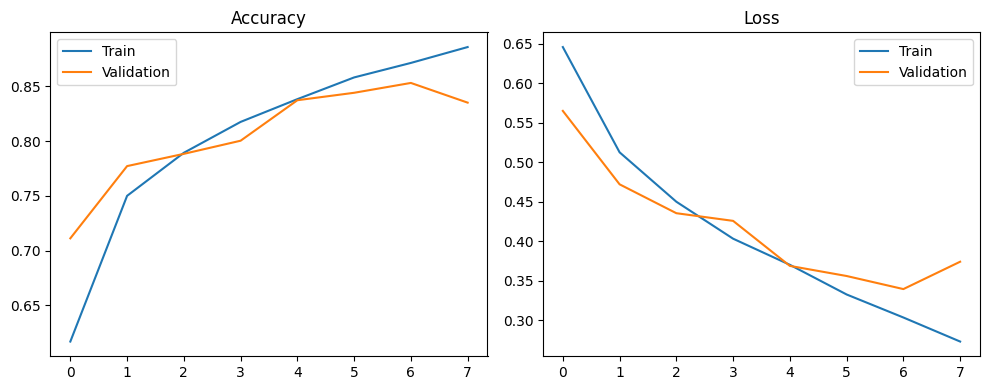

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 4) Predict a New Image (URL or Local Windows Path)

Use this cell to classify:
- an internet image URL, or
- a local image file path from your Windows laptop.

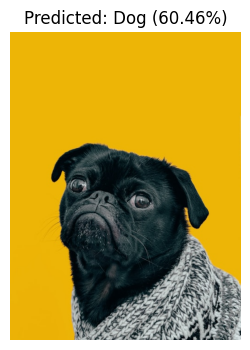

{'class': 'Dog', 'confidence': 0.6046}


In [9]:
inference_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


def load_image(image_source: str) -> Image.Image:
    src = image_source.strip()
    if src.lower().startswith(("http://", "https://")):
        response = requests.get(src, timeout=20)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")

    path = pathlib.Path(src)
    if not path.is_absolute():
        path = (PROJECT_DIR / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return Image.open(path).convert("RGB")


def predict_image(image_source: str):
    model.eval()
    image = load_image(image_source)
    display_image = image.copy()

    image_tensor = inference_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logit = model(image_tensor)
        dog_prob = torch.sigmoid(logit).item()

    predicted_class = class_names[1] if dog_prob >= 0.5 else class_names[0]
    confidence = dog_prob if dog_prob >= 0.5 else 1.0 - dog_prob

    plt.figure(figsize=(4, 4))
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class} ({confidence * 100:.2f}%)")
    plt.show()

    print({"class": predicted_class, "confidence": round(confidence, 4)})


# Example 1: internet URL
image_source = "https://images.unsplash.com/photo-1517849845537-4d257902454a?w=500"

# Example 2: local Windows file (uncomment this line and set your path)
# image_source = r"C:\\Users\\heman\\Downloads\\my_pet.jpg"

predict_image(image_source)